# Pancreatic MatchMaker — Colab A100 Runner

1. **Clone** the repo (GitHub).
2. **Install** deps.
3. **Knobs** (seeds, `RAW_CSV`, hyperparameters).
4. **Copy `data/` from Google Drive** — My Drive root → `./data/` (chem + synergy CSVs).
5. **Preprocess** → processed TSVs.
6. **Splits** (LTO / LPO / …).
7. **Train** (`scripts/run_experiments.py`).
8. **Report**.

Optional: copy `results/` and `splits/` to Drive using the cell at the end (`SAVE_TO_DRIVE`).

Defaults: **min–max** norm, **uniform** weights.

**Runtime → Change runtime type → GPU** before training.

For **Optuna hyperparameter search** (one split / seed), use **`hyperparameter_tuning.ipynb`** in this folder — the main pipeline does not auto-tune.



In [23]:
# Quick file check — run AFTER **Load codebase**
from pathlib import Path

for name in ('helper_funcs.py', 'MatchMaker.py'):
    p = Path(name)
    print(name, 'OK' if p.exists() else 'MISSING — run checkout cell first')

hf = Path('helper_funcs.py')
if hf.exists():
    t = hf.read_text(encoding='utf-8', errors='replace')
    print('helper_funcs.py: minmax scaling path:', "minmax" in t and "'minmax'" in t)
mm = Path('MatchMaker.py')
if mm.exists():
    t = mm.read_text(encoding='utf-8', errors='replace')
    print('MatchMaker.py: TerminateOnNaN in trainer:', 'TerminateOnNaN' in t)


helper_funcs.py OK
MatchMaker.py OK
helper_funcs.py: minmax scaling path: True
MatchMaker.py: TerminateOnNaN in trainer: True


In [24]:
import os
import shutil

# Cleanup before cloning (run once per fresh session).
# Must chdir out of the tree we delete — otherwise cwd becomes invalid and later git/subprocess calls fail.
os.chdir("/content")
shutil.rmtree("/content/matchmaker_test", ignore_errors=True)
print("Removed /content/matchmaker_test if it existed.")


Removed /content/matchmaker_test if it existed.


In [25]:
# --- Load codebase from GitHub ---
import os
import shutil
import subprocess
import time
from pathlib import Path

GIT_REPO_URL = "https://github.com/ENS491-Project-360-Team/ens_492.git"
GIT_BRANCH = "main"
CLONE_PARENT = Path("/content/matchmaker_test")

# If cwd is inside CLONE_PARENT, deleting it breaks git ("Unable to read current working directory").
os.chdir("/content")

shutil.rmtree(CLONE_PARENT, ignore_errors=True)

cmd = ["git", "clone", "--depth", "1", "--branch", GIT_BRANCH, GIT_REPO_URL, str(CLONE_PARENT)]
print("Running:", " ".join(cmd))
env = {**os.environ, "GIT_TERMINAL_PROMPT": "0"}
last = None
for attempt in range(1, 4):
    proc = subprocess.run(cmd, capture_output=True, text=True, env=env)
    last = proc
    if proc.returncode == 0:
        break
    print(f"git clone failed (attempt {attempt}/3), stderr:\n{proc.stderr or proc.stdout or '(no output)'}")
    if attempt < 3:
        time.sleep(4)
if last.returncode != 0:
    raise RuntimeError(
        "git clone failed after 3 attempts. If stderr mentioned cwd, re-run this cell. "
        "Else: network hiccup / private repo (use https://TOKEN@github.com/...)."
    )

if (CLONE_PARENT / "ens_492" / "main.py").exists():
    WORKDIR = CLONE_PARENT / "ens_492"
elif (CLONE_PARENT / "main.py").exists():
    WORKDIR = CLONE_PARENT
else:
    raise FileNotFoundError("Clone OK but main.py not found under clone root or ens_492/.")

os.chdir(WORKDIR)
os.environ["MATCHMAKER_ROOT"] = str(WORKDIR.resolve())
print("Working directory:", Path.cwd())


Running: git clone --depth 1 --branch main https://github.com/ENS491-Project-360-Team/ens_492.git /content/matchmaker_test
Working directory: /content/matchmaker_test


In [26]:
# Optional: debug Colab paths (ignore if `import tensorflow` next cell works)
!pwd

/content/matchmaker_test


In [27]:
# 2) Install dependencies
!python -m pip install -q --upgrade pip
!python -m pip install -q numpy pandas scipy scikit-learn tensorflow

import tensorflow as tf
print('TF version:', tf.__version__)
!nvidia-smi

TF version: 2.20.0
Mon May  4 12:31:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+----------------------------

In [28]:
# 3) Configure experiment knobs
SEEDS = [42]
RUN_TRAINING = True   # set False to only test preprocessing/splits
GPU_DEVICES = '0'

# Classification threshold for converting regression score to class prediction
CLASSIFICATION_THRESHOLD = 0.0

# Raw data: path relative to repo root, or basename if the file lives in `data/`
# (Step A checks cwd first, then `data/<basename>` when `RAW_CSV` has no folder).
# Use the exact filename on disk (sheet export often has spaces).
RAW_CSV = 'synergy - comb - Combination data.csv'

# Training / preprocessing (passed to scripts/run_experiments.py -> main.py)
# Defaults: merged pipeline (Arda-style min-max + selectable weights).
NORM = 'minmax'   # alternatives: tanh_norm, norm, tanh
WEIGHT_MODE = 'uniform'   # uniform | q3_upweight | log
WEIGHT_ALPHA = 3.0   # q3_upweight only
LR = 1e-4
INPUT_DROPOUT = 0.2
DROPOUT = 0.5
BATCH_SIZE = 128
MAX_EPOCH = 1000
EARLYSTOP = 100

print('SEEDS:', SEEDS)
print('RUN_TRAINING:', RUN_TRAINING)
print('RAW_CSV:', RAW_CSV)
print('NORM:', NORM, '| WEIGHT_MODE:', WEIGHT_MODE, '| LR:', LR, '| BATCH_SIZE:', BATCH_SIZE)

# Backup to Drive (optional). Step 9 copies results/splits when SAVE_TO_DRIVE is True.
from pathlib import Path

SAVE_TO_DRIVE = False
DRIVE_BACKUP_ROOT = Path('/content/drive/MyDrive/matchmaker_runs')



SEEDS: [42]
RUN_TRAINING: True
RAW_CSV: synergy - comb - Combination data.csv
NORM: minmax | WEIGHT_MODE: uniform | LR: 0.0001 | BATCH_SIZE: 128


In [29]:
# 4) Copy data from Google Drive (My Drive root → `./data/`)
#
# Upload those files to the top of "My Drive", then run this after **Load codebase**.

from pathlib import Path
import shutil

from google.colab import drive

drive.mount("/content/drive")

MYDRIVE = Path("/content/drive/MyDrive")
dest_dir = Path("data")
dest_dir.mkdir(parents=True, exist_ok=True)

required = [
    "drug1_chem.csv",
    "drug2_chem.csv",
    "cell_line_gex.csv",
    "synergy - comb - Combination data.csv",
]

for name in required:
    src = MYDRIVE / name
    if not src.is_file():
        raise FileNotFoundError(
            "Not on Drive at {!r}. Open Drive → confirm the name matches exactly, then re-run.\n"
            "List folder: !ls -la '/content/drive/MyDrive'".format(src)
        )
    shutil.copy2(src, dest_dir / name)
    print("OK:", dest_dir / name)

# Optional leftovers on your Drive (pipeline can ignore if you use generated splits)
for name in ("DrugCombinationData.tsv", "train_inds.txt", "val_inds.txt", "test_inds.txt"):
    src = MYDRIVE / name
    if src.is_file():
        shutil.copy2(src, dest_dir / name)
        print("OK (extra):", dest_dir / name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK: data/drug1_chem.csv
OK: data/drug2_chem.csv
OK: data/cell_line_gex.csv
OK: data/synergy - comb - Combination data.csv
OK (extra): data/DrugCombinationData.tsv
OK (extra): data/train_inds.txt
OK (extra): data/val_inds.txt
OK (extra): data/test_inds.txt


In [30]:
# 5) Step A - preprocess pancreatic data (writes unfiltered + Bliss-variance–filtered)
# Variance filter: IQR rule on replicate Bliss variance per (pair, cell) — same spirit as meeting4_dataprocessing.ipynb (without quartile class labels).
# Pure Python (no shell heredoc) — avoids NameError on stray `PY` in Colab/Cursor.
import os
import subprocess
import sys
import pandas as pd
from pathlib import Path

_raw = Path(RAW_CSV)
_candidates = [_raw.resolve()]
if not _raw.is_absolute() and _raw.parent == Path("."):
    _candidates.append((Path("data") / _raw.name).resolve())
csv_path = next((p for p in _candidates if p.is_file()), None)
if csv_path is None:
    tried = ", ".join(str(p) for p in _candidates)
    raise FileNotFoundError(
        "Raw CSV not found. Tried: "
        + tried
        + ". Set `RAW_CSV` to the path under your working directory (e.g. `data/yourfile.csv`) "
        "or upload the file to `data/` and keep the basename in `RAW_CSV`."
    )
print("Using raw CSV:", csv_path)

r = subprocess.run(
    [sys.executable, "scripts/prepare_pancreatic_data.py", "--raw-csv", str(csv_path), "--out-dir", "data/processed"],
    capture_output=True,
    text=True,
)
print(r.stdout)
if r.stderr:
    print(r.stderr)
r.check_returncode()
print('data/processed:', os.listdir('data/processed'))
print('unfiltered shape:', pd.read_csv('data/processed/pancreatic_unfiltered.tsv', sep='\t').shape)
print('variance_filtered shape:', pd.read_csv('data/processed/pancreatic_variance_filtered.tsv', sep='\t').shape)


Using raw CSV: /content/matchmaker_test/data/synergy - comb - Combination data.csv
Excluded rows with source='Nature': 496 (66796 raw rows before → 66300 after).
Wrote: data/processed/pancreatic_unfiltered.tsv
Wrote: data/processed/pancreatic_variance_filtered.tsv
Wrote: data/processed/data_card.md

data/processed: ['data_card.md', 'pancreatic_unfiltered.tsv', 'pancreatic_variance_filtered.tsv']
unfiltered shape: (9397, 11)
variance_filtered shape: (8702, 11)


In [31]:
# 6) Step B - generate split files (LTO/LPO/LCO/LODO/LDO)
import json
import os
import subprocess
import sys

seed_args = [str(s) for s in SEEDS]
subprocess.run(
    [sys.executable, 'scripts/generate_splits.py', '--input-tsv', 'data/processed/pancreatic_variance_filtered.tsv',
     '--outdir', 'splits', '--seeds'] + seed_args,
    check=True,
)
print('splits:', os.listdir('splits'))
with open('splits/leakage_report.json') as f:
    leak = json.load(f)
print('num leakage entries:', len(leak))
print('example:', leak[0])


splits: ['ldo', 'lodo', 'leakage_report.json', 'lto', 'lpo', 'lco']
num leakage entries: 5
example: {'pair_overlap': 325, 'drug_overlap': 26, 'cell_overlap': 29, 'n_train': 5570, 'n_test': 1740, 'split': 'lto', 'seed': 42, 'folder': 'splits/lto/seed_42'}


In [32]:
# 7) Step C - optional dry run to verify command matrix
import os
import subprocess
import sys

seed_args = [str(s) for s in SEEDS]
cmd = (
    [sys.executable, '-u', 'scripts/run_experiments.py',
     '--project-root', '.', '--seeds'] + seed_args
    + ['--splits-root', 'splits',
       '--processed-root', 'data/processed',
       '--out-root', 'results/runs',
       '--gpu-devices', GPU_DEVICES,
       '--classification-threshold', str(CLASSIFICATION_THRESHOLD),
       '--norm', NORM,
       '--weight-mode', WEIGHT_MODE,
       '--weight-alpha', str(WEIGHT_ALPHA),
       '--lr', str(LR),
       '--input-dropout', str(INPUT_DROPOUT),
       '--dropout', str(DROPOUT),
       '--batch-size', str(BATCH_SIZE),
       '--max-epoch', str(MAX_EPOCH),
       '--earlystop', str(EARLYSTOP),
       '--dry-run']
)
subprocess.run(cmd, check=True, env={**os.environ, 'PYTHONUNBUFFERED': '1'})


CompletedProcess(args=['/usr/bin/python3', '-u', 'scripts/run_experiments.py', '--project-root', '.', '--seeds', '42', '--splits-root', 'splits', '--processed-root', 'data/processed', '--out-root', 'results/runs', '--gpu-devices', '0', '--classification-threshold', '0.0', '--norm', 'minmax', '--weight-mode', 'uniform', '--weight-alpha', '3.0', '--lr', '0.0001', '--input-dropout', '0.2', '--dropout', '0.5', '--batch-size', '128', '--max-epoch', '1000', '--earlystop', '100', '--dry-run'], returncode=0)

In [33]:
# 8) Step D - full training matrix
# This runs: {unfiltered, filtered} x {lto,lpo,lco,lodo,ldo} x seeds
# main.py also needs gitignored feature files under `data/` (drug descriptors + cell GEX) — same as local zip.
#
# Stream child stdout + 30s heartbeat. Long quiet periods are normal (TensorFlow import, CSV I/O, first GPU compile).
import os
import subprocess
import sys
import threading
import time
from pathlib import Path

if RUN_TRAINING:
    need = [
        Path("data/drug1_chem.csv"),
        Path("data/drug2_chem.csv"),
        Path("data/cell_line_gex.csv"),
    ]
    missing = [p for p in need if not p.is_file()]
    if missing:
        raise FileNotFoundError(
            "Training requires descriptor/GEX CSVs in `data/` (not created by preprocessing). "
            "Copy from your full project `data/` (or unzip `data.zip`) into this repo on Colab. Missing:\n  "
            + "\n  ".join(str(p) for p in missing)
        )

    seed_args = [str(s) for s in SEEDS]
    cmd = (
        [sys.executable, "-u", "scripts/run_experiments.py",
         "--project-root", ".", "--seeds"] + seed_args
        + ["--splits-root", "splits",
           "--processed-root", "data/processed",
           "--out-root", "results/runs",
           "--gpu-devices", GPU_DEVICES,
           "--classification-threshold", str(CLASSIFICATION_THRESHOLD),
           "--norm", NORM,
           "--weight-mode", WEIGHT_MODE,
           "--weight-alpha", str(WEIGHT_ALPHA),
           "--lr", str(LR),
           "--input-dropout", str(INPUT_DROPOUT),
           "--dropout", str(DROPOUT),
           "--batch-size", str(BATCH_SIZE),
           "--max-epoch", str(MAX_EPOCH),
           "--earlystop", str(EARLYSTOP)]
    )
    env = {**os.environ, "PYTHONUNBUFFERED": "1"}
    print("Running:", " ".join(cmd), flush=True)

    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    hb_on = {"run": True}

    def heartbeat():
        t0 = time.monotonic()
        while hb_on["run"] and proc.poll() is None:
            time.sleep(30)
            if proc.poll() is None:
                print(
                    "[heartbeat] still running — {}s since cell start (data load / TF / first epoch can take several minutes)".format(
                        int(time.monotonic() - t0)
                    ),
                    flush=True,
                )

    thb = threading.Thread(target=heartbeat, daemon=True)
    thb.start()

    try:
        for line in iter(proc.stdout.readline, ""):
            print(line, end="", flush=True)
    finally:
        hb_on["run"] = False

    rc = proc.wait()
    if rc != 0:
        raise RuntimeError(
            "run_experiments / main.py exited with {}. Scroll up for traceback.".format(rc)
        )
else:
    print("RUN_TRAINING is False, skipping training.")



Running: /usr/bin/python3 -u scripts/run_experiments.py --project-root . --seeds 42 --splits-root splits --processed-root data/processed --out-root results/runs --gpu-devices 0 --classification-threshold 0.0 --norm minmax --weight-mode uniform --weight-alpha 3.0 --lr 0.0001 --input-dropout 0.2 --dropout 0.5 --batch-size 128 --max-epoch 1000 --earlystop 100


>>> run_experiments (1/10)  dataset=unfiltered  split=lto  seed=42
Running: /usr/bin/python3 -u main.py --comb-data-name data/processed/pancreatic_unfiltered.tsv --label-column synergy_loewe --classification-label-column synergy_binary --classification-threshold 0.0 --train-ind splits/lto/seed_42/train_inds.txt --val-ind splits/lto/seed_42/val_inds.txt --test-ind splits/lto/seed_42/test_inds.txt --split-mode files --saved-model-name matchmaker.h5 --outdir results/runs/unfiltered/lto/seed_42 --gpu-devices 0 --train-test-mode 1 --norm minmax --weight-mode uniform --weight-alpha 3.0 --lr 0.0001 --input-dropout 0.2 --dropout 0.5 --batch-size 128 --max-epoch 1000 --earlystop 100 --seed 42
[matchmaker 12:31:21] start main.py — comb_data='data/processed/pancreatic_unfiltered.tsv' outdir='results/runs/unfiltered/lto/seed_42' seed=42
[matchmaker 12:31:21] TensorFlow 2.20.0 | CUDA_VISIBLE_DEVICES=0 | gpu_support=True
[matchmaker 12:31:21] loading drug/cell features + combination table (I/O can t

In [34]:
# 9) Step E - build summary report
import subprocess
import sys
from pathlib import Path

if RUN_TRAINING:
    subprocess.run(
        [
            sys.executable,
            "scripts/build_report.py",
            "--summary-csv",
            "results/summary_metrics.csv",
            "--per-seed-csv",
            "results/per_split_seed_metrics.csv",
            "--out-md",
            "results/report.md",
        ],
        check=True,
    )
    res = Path("results")
    if res.is_dir():
        print("results:", sorted(p.name for p in res.iterdir()))
    rep = Path("results/report.md")
    if rep.is_file():
        text = rep.read_text(encoding="utf-8", errors="replace")
        print(text[:4000])
        if len(text) > 4000:
            print("\n... [truncated]")
else:
    print("RUN_TRAINING is False, no report to build.")



results: ['per_split_seed_metrics.csv', 'report.md', 'runs', 'summary_metrics.csv']
# Pancreatic MatchMaker report

## Inputs

- Summary metrics: `results/summary_metrics.csv`
- Per-seed metrics: `results/per_split_seed_metrics.csv`

## Best stable scenario

- Regression winner: dataset=`None`, split=`None`, MSE=`1.2420`, Pearson=`0.5257`
- Classification winner: dataset=`None`, split=`None`, F1=`0.6990`
- Ranking winner (AUC/AUPRC): dataset=`None`, split=`None`, AUC=`0.7270`, AUPRC=`0.7985`

## Split difficulty trend

- Mean MSE by split:
  - lto: 1.4319
  - lpo: 2.0940
  - lco: 1.3591
  - lodo: 1.9797
  - ldo: 2.2823

## Disagreement filter impact

- `lco`: MSE delta(filtered-unfiltered)=-0.2342; F1 delta(filtered-unfiltered)=-0.0158
- `ldo`: MSE delta(filtered-unfiltered)=0.4276; F1 delta(filtered-unfiltered)=-0.2265
- `lodo`: MSE delta(filtered-unfiltered)=-0.0645; F1 delta(filtered-unfiltered)=-0.0076
- `lpo`: MSE delta(filtered-unfiltered)=-0.3704; F1 delta(filtered-unfiltered)=-

In [35]:
# 10) Optional: copy outputs to Drive (set SAVE_TO_DRIVE + RUN_TRAINING in knobs cell)
from pathlib import Path
import os
import shutil

ROOT = Path(os.environ.get("MATCHMAKER_ROOT", ".")).resolve()

if SAVE_TO_DRIVE and RUN_TRAINING:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_BACKUP_ROOT.mkdir(parents=True, exist_ok=True)
    tgt = DRIVE_BACKUP_ROOT / "results"
    if tgt.exists():
        shutil.rmtree(tgt)
    shutil.copytree(ROOT / "results", tgt)
    print("Copied results to", tgt)

    stgt = DRIVE_BACKUP_ROOT / "splits"
    if stgt.exists():
        shutil.rmtree(stgt)
    shutil.copytree(ROOT / "splits", stgt)
    print("Copied splits to", stgt)
else:
    print("Drive copy skipped.")


Drive copy skipped.


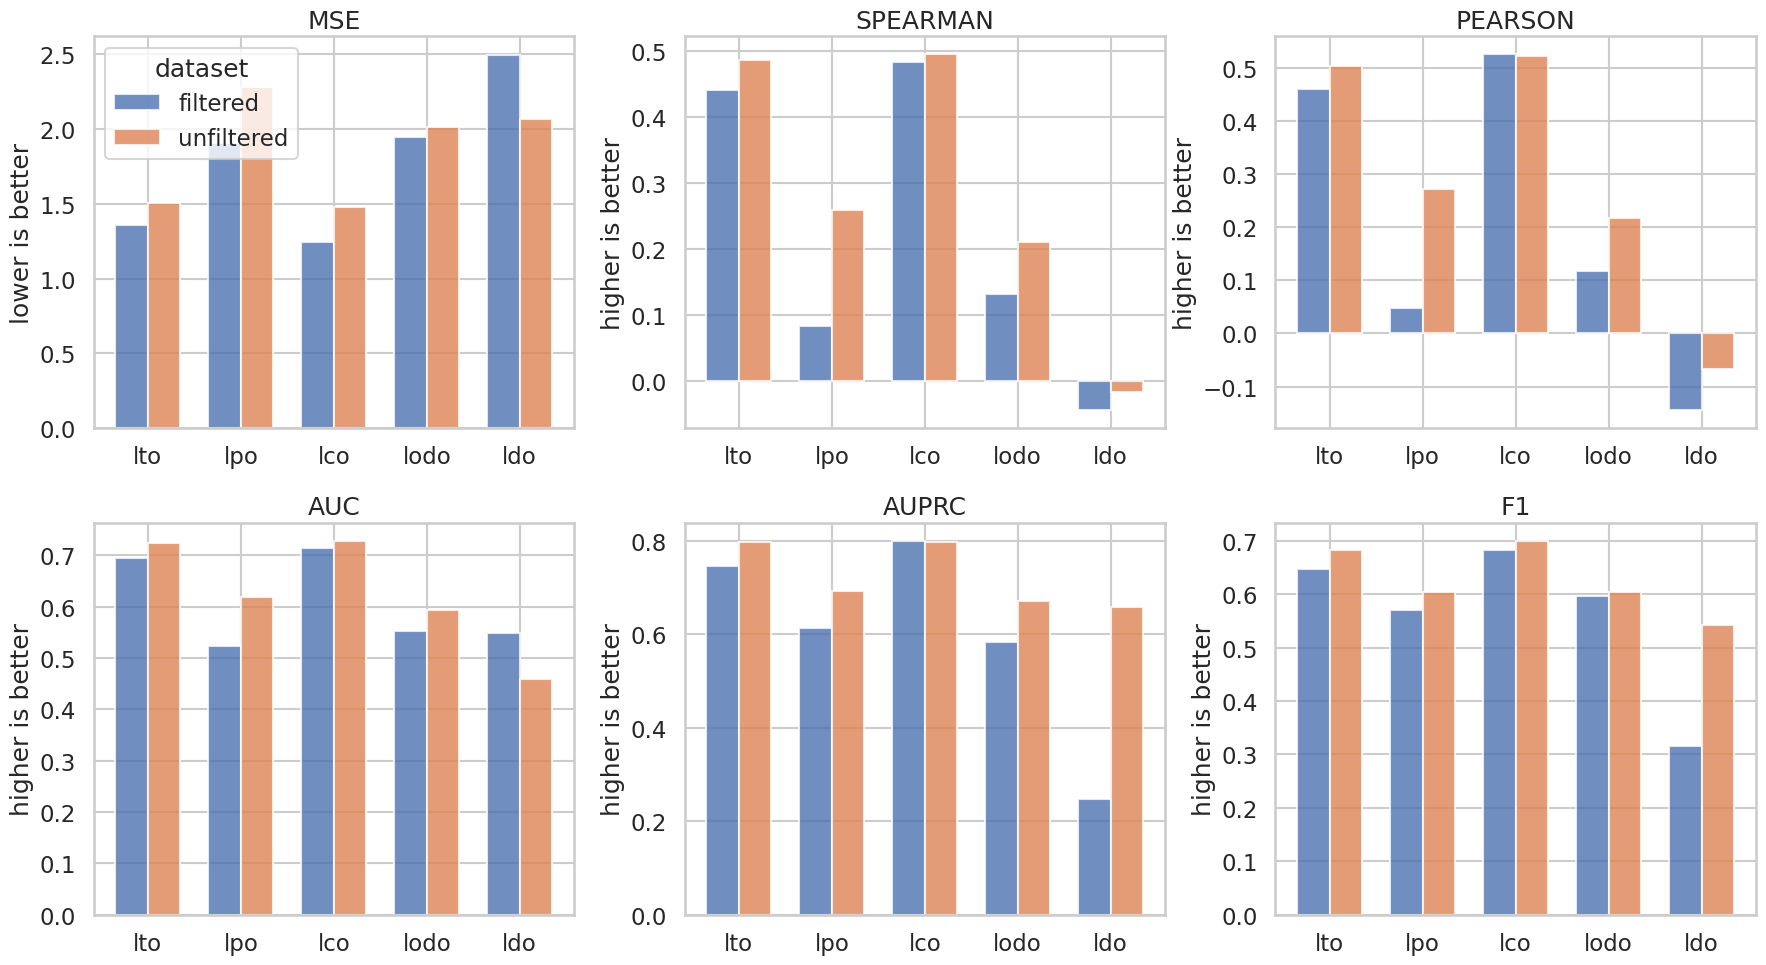

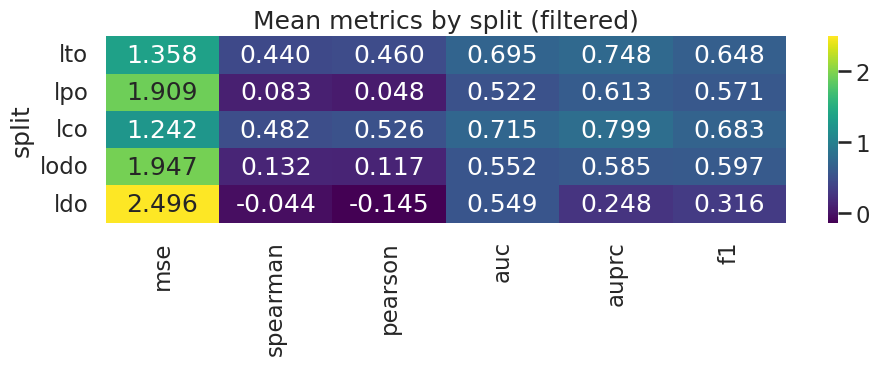

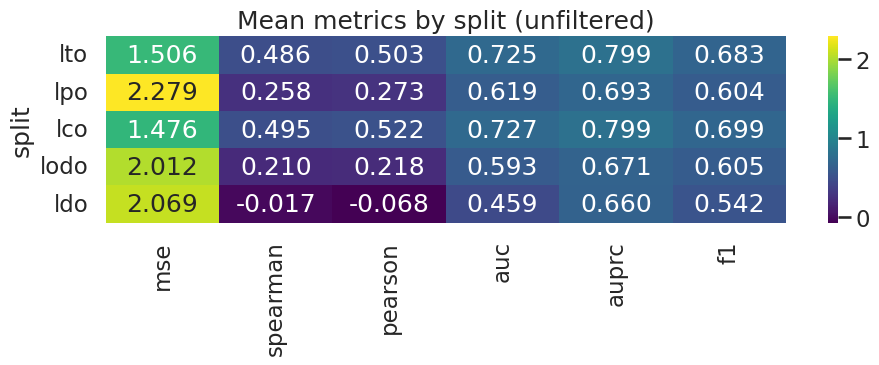

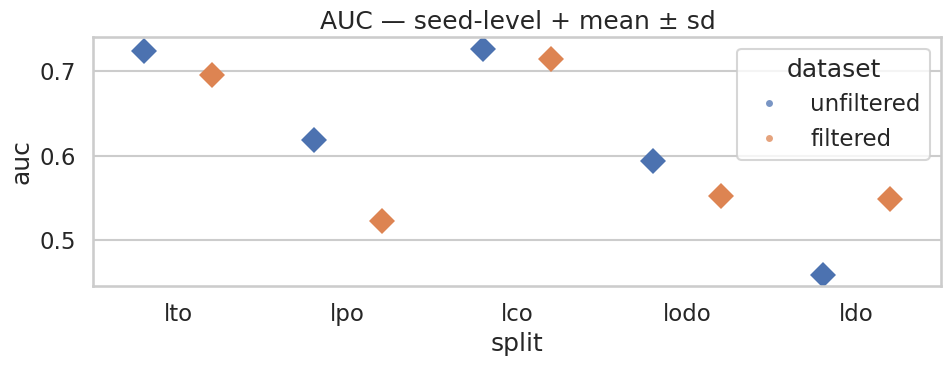

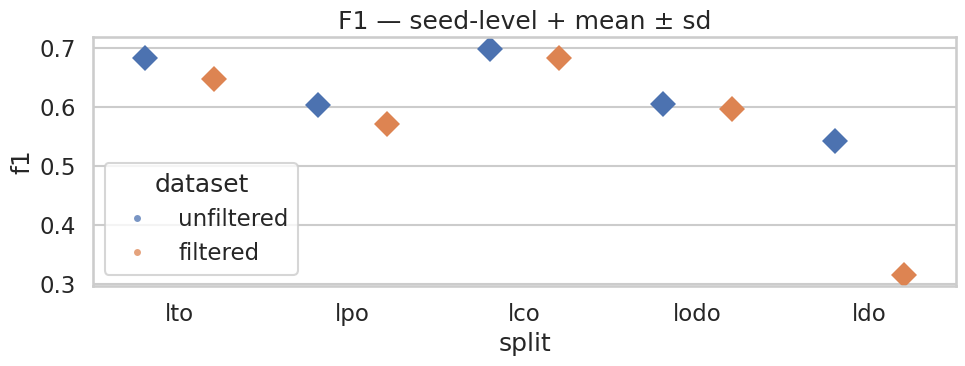

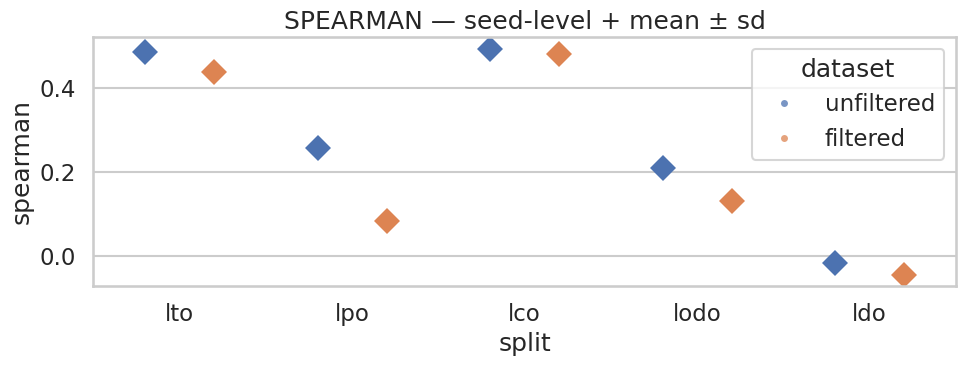

In [36]:
!python -m pip install -q seaborn
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Primary: aggregated metrics from scripts/run_experiments.py → results/per_split_seed_metrics.csv
csv_path = Path("results/per_split_seed_metrics.csv")

# Optional fallback: uncomment and set if training wrote outputs elsewhere / you copied from Drive.
# csv_path = Path("/content/drive/MyDrive/matchmaker_runs/.../results/per_split_seed_metrics.csv")

if not csv_path.is_file():
    raise FileNotFoundError(
        "No metrics file at {!r}. Run Step D (training) first, or set csv_path.".format(csv_path.resolve())
    )

df = pd.read_csv(csv_path)

split_order = ["lto", "lpo", "lco", "lodo", "ldo"]
df["split"] = pd.Categorical(df["split"], categories=split_order, ordered=True)

metrics = ["mse", "spearman", "pearson", "auc", "auprc", "f1"]

# ---- aggregate mean±std over seeds ----
agg = (
    df.groupby(["dataset", "split"], observed=True)[metrics]
    .agg(["mean", "std"])
    .reset_index()
)
agg.columns = ["dataset", "split"] + ["{}_{}".format(m, s) for m in metrics for s in ["mean", "std"]]

# ---- 1) Bar charts mean±std (2×3) ----
sns.set(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, m in enumerate(metrics):
    ax = axes[i]
    sub = agg[["dataset", "split", "{}_mean".format(m), "{}_std".format(m)]].copy()
    for j, ds in enumerate(sorted(sub["dataset"].unique())):
        ds_sub = sub[sub["dataset"] == ds].sort_values("split")
        x = np.arange(len(ds_sub)) + (j - 0.5) * 0.35
        ax.bar(x, ds_sub["{}_mean".format(m)], width=0.35, label=ds if i == 0 else None, alpha=0.8)
        ax.errorbar(
            x,
            ds_sub["{}_mean".format(m)],
            yerr=ds_sub["{}_std".format(m)],
            fmt="none",
            capsize=3,
            color="black",
            lw=1,
        )

    ax.set_title(m.upper())
    ax.set_xticks(np.arange(len(split_order)))
    ax.set_xticklabels(split_order)
    ax.set_ylabel("lower is better" if m == "mse" else "higher is better")

axes[0].legend(title="dataset")
plt.tight_layout()
plt.show()

# ---- 2) Heatmaps of mean metric matrix (one figure per dataset) ----
for ds in sorted(df["dataset"].unique()):
    mat = (
        df.loc[df["dataset"] == ds]
        .groupby("split", observed=True)[metrics]
        .mean()
        .reindex(split_order)
    )

    plt.figure(figsize=(10, 4))
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Mean metrics by split ({})".format(ds))
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ---- 3) Seed-level strip + aggregate point (± SD) ----
for m in ["auc", "f1", "spearman"]:
    plt.figure(figsize=(10, 4))
    sns.stripplot(data=df, x="split", y=m, hue="dataset", dodge=True, alpha=0.75)

    kwargs = dict(data=df, x="split", y=m, hue="dataset", dodge=0.4, markers="D", linestyles="", legend=False)
    try:
        sns.pointplot(**kwargs, errorbar="sd")
    except TypeError:
        sns.pointplot(**kwargs, ci="sd")

    plt.title("{} — seed-level + mean ± sd".format(m.upper()))
    plt.tight_layout()
    plt.show()

## Troubleshooting

- **GitHub:** Edit `GIT_REPO_URL` / `GIT_BRANCH` in **Load codebase**. Private repo: `https://TOKEN@github.com/org/repo.git`.
- **Data:** Put `drug1_chem.csv`, `drug2_chem.csv`, `cell_line_gex.csv`, and `synergy - comb - Combination data.csv` in **My Drive** (root is fine), then run **Copy data from Google Drive** — names must match exactly.
- **Git / cwd:** If clone says it cannot read cwd, run the **cleanup** cell, then **Load codebase** again.
- **OOM:** Lower `BATCH_SIZE` in knobs.
- **Legacy recipe:** `NORM = 'tanh_norm'`, `WEIGHT_MODE = 'log'` in knobs before training.
